In [1]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)

# https://drive.google.com/file/d/1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo/view?usp=sharing # tif delta 1+7 ref + indices
!gdown --id 1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo

# https://drive.google.com/file/d/1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd/view?usp=sharing # polygons samples geojson
!gdown --id 1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1iSqvJEIomtpR6US82bIoFAB-M0-hRWYo
To: /content/stack_1-7&indices.tif
100% 9.44M/9.44M [00:00<00:00, 20.5MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1SZCmuF-_38kcTH1ESU0SsKrvvGlCWtkd
To: /content/samples_delta.geojson
100% 18.5k/18.5k [00:00<00:00, 32.5MB/s]


In [22]:
# INSTALL LIBRARIES AND DEPENDENCIES
import pandas as pd
import geopandas as gpd
!pip install rasterio
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from rasterio.mask import mask
from shapely.geometry import mapping

In [4]:
# OPEN L8 SCENE IN RASTER FILE AND EXTRACT DATA

# open de raster
tif_path = f'/content/stack_1-7&indices.tif'
tif = rasterio.open(tif_path)

# extract bands names
bands_list = [f'b{i}' for i in range(1, 8)] # 1-7 bands

In [6]:
# read vector file with sampling areas
path_vector = '/content/samples_delta.geojson'
gdf_samples = gpd.read_file(path_vector).to_crs(tif.crs) # assign to the vector file the same crs as the tif

## visualize geodataframe
gdf_samples.head()

,id,cobertura,geometry
0,1,rio,"MULTIPOLYGON (((176645.609 -3672894.936, 17665..."
1,2,humedal,"MULTIPOLYGON (((184605.544 -3672560.284, 18462..."
2,3,urbano,"MULTIPOLYGON (((176048.016 -3677603.966, 17606..."
3,4,cultivo,"MULTIPOLYGON (((180637.528 -3678560.115, 18063..."


In [25]:
# extract bands reflectance for sampling areas
def df_firms_data(tif, gdf_samples, gdf_idx, bands_names):

  geoms = gdf_samples.geometry.values

  # transform to GeJSON format (???)
  geoms = [mapping(geoms[gdf_idx])]

  out_image, out_transform = mask(tif , geoms, crop=True) # recorta la imagen segun ROI

  ma_data = np.ma.masked_equal(out_image, 0) # convierte los valores igual a 0 en Nan

  df_bands_data = pd.DataFrame()

  for i in range(len(bands_names)):
      df_bands_data[bands_names[i]] = ma_data[i].flatten()

  return df_bands_data

# calculate mean and std for each sampling area per band and store it as a numpy array
def mean_std_firms(df_firms_data):

    bands_list = df_firms_data.columns.values

    list_mean = []
    list_std = []

    for b in bands_list:
        list_mean.append(np.mean(df_firms_data[b]))
        list_std.append(np.std(df_firms_data[b]))

    return np.array(list_mean), np.array(list_std)


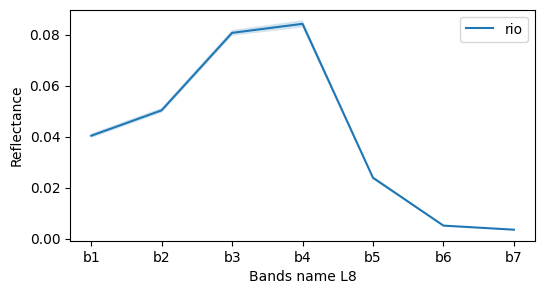

In [26]:
gdf_idx = 0
id = gdf_samples.loc[gdf_idx].cobertura # NOTE: the description is defined as "cobertura here". changed it as need it
fe_mean, fe_std = mean_std_firms(df_firms_data(tif, gdf_samples, gdf_idx, bands_list))

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(bands_list, fe_mean, label = id)
ax.fill_between(bands_list, fe_mean - fe_std, fe_mean + fe_std, alpha=0.2)
ax.set_xlabel('Bands name L8')
ax.set_ylabel('Reflectance')
ax.legend(loc='best')

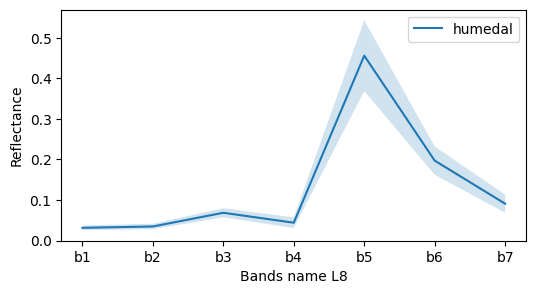

In [27]:
gdf_idx = 1
id = gdf_samples.loc[gdf_idx].cobertura

fe_mean, fe_std = mean_std_firms(df_firms_data(tif, gdf_samples, gdf_idx, bands_list))

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(bands_list, fe_mean, label = id)
ax.fill_between(bands_list, fe_mean - fe_std, fe_mean + fe_std, alpha=0.2)
ax.set_xlabel('Bands name L8')
ax.set_ylabel('Reflectance')
ax.legend(loc='best')

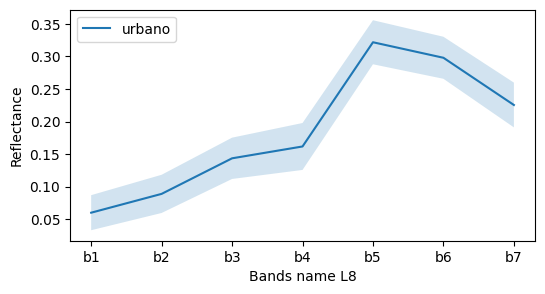

In [28]:
gdf_idx = 2
id = gdf_samples.loc[gdf_idx].cobertura

fe_mean, fe_std = mean_std_firms(df_firms_data(tif, gdf_samples, gdf_idx, bands_list))

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(bands_list, fe_mean, label = id)
ax.fill_between(bands_list, fe_mean - fe_std, fe_mean + fe_std, alpha=0.2)
ax.set_xlabel('Bands name L8')
ax.set_ylabel('Reflectance')
ax.legend(loc='best')

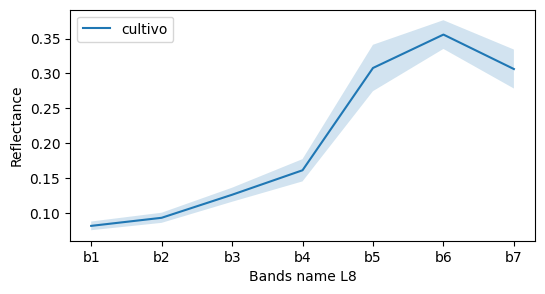

In [29]:
gdf_idx = 3
id = gdf_samples.loc[gdf_idx].cobertura

fe_mean, fe_std = mean_std_firms(df_firms_data(tif, gdf_samples, gdf_idx, bands_list))

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(bands_list, fe_mean, label = id)
ax.fill_between(bands_list, fe_mean - fe_std, fe_mean + fe_std, alpha=0.2)
ax.set_xlabel('Bands name L8')
ax.set_ylabel('Reflectance')
ax.legend(loc='best')